### 통신사 고객 이탈 예측(Telco Customer Churn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Telco.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


TotalCharges 값이 object(문자열)로 되어 있는 걸 보니 공백이나 특수 문자가 있을 가능성이 있음

In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

pd.to_numeric의 error = coerce를 사용해 결측치로 변환

In [3]:
print(df['TotalCharges'].isnull().sum())

11


결측치가 전체 7043개 중 11개(약 0.15%)이므로 삭제

In [4]:
df.dropna(inplace = True)

In [5]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

customerID는 분석에 필요 없으므로 삭제

In [6]:
df = df.drop('customerID', axis = 1)

In [7]:
print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

고객 이탈을 예측해야하므로 타겟 변수는 Churn

Churn은 No(잔존)와 Yes(이탈)로 이루어져 있으니 0과 1로 변환

In [8]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

0과 1로 변환했으니 확인하고, 비율도 확인

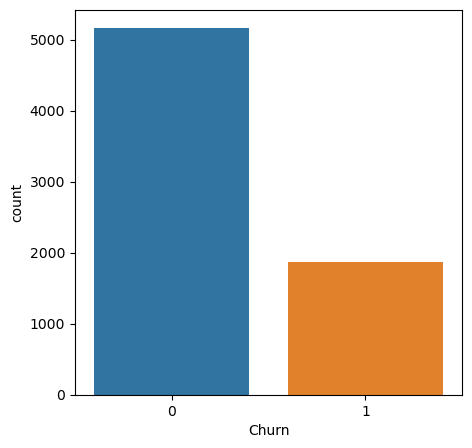

In [9]:
plt.figure(figsize = (5,5))
sns.countplot(x = 'Churn', data = df)
plt.show()

In [10]:
print(df['Churn'].value_counts(normalize = True))

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


확인해보니 0(잔존)이 73%, 1(이탈)이 26%

이탈하는 이유를 찾기 위해 가설 세우기

ex) 월 요금(MonthlyCharges)이 높아서?

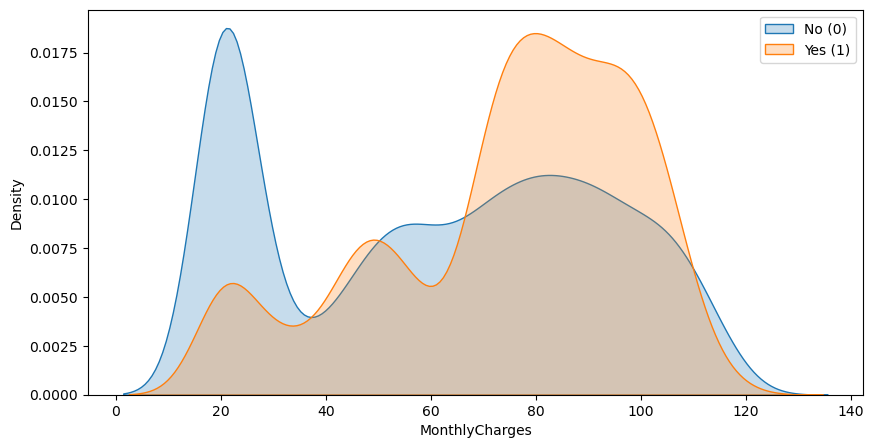

In [11]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize = (10,5))
sns.kdeplot(df[df['Churn'] == 0]['MonthlyCharges'], label = 'No (0)', shade = True)
sns.kdeplot(df[df['Churn'] == 1]['MonthlyCharges'], label = 'Yes (1)', shade = True)
plt.legend()
plt.show()

주황색 이탈자 그래프가 높은 요금 구간으로 치우쳐 있으므로

'월 요금이 높은 고객이 이탈할 확률이 높다' 라는 가설을 설명할 수 있음

또 다른 영향이 있는지 확인 ex) 약정(Contract)이 없는(Month-to-month) 고객이 쉽게 떠날 것?

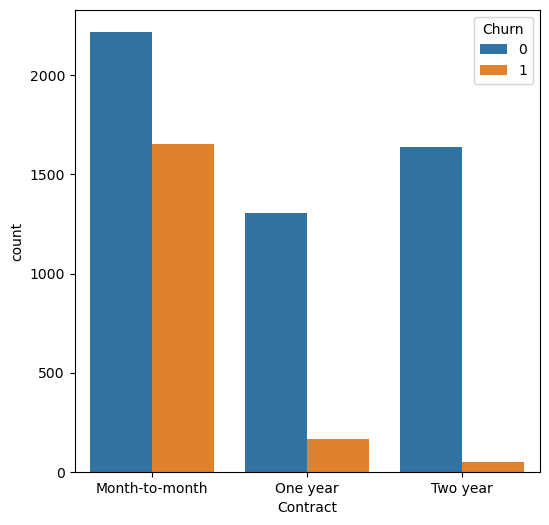

In [12]:
plt.figure(figsize = (6, 6))
plot_df = df.copy()
plot_df['Churn'] = plot_df['Churn'].astype(str) # 0과 1로 바꾼 Churn 컬럼을 잠시 문자 취급
sns.countplot(x = 'Contract', hue = 'Churn', data = plot_df)
plt.show()

Month-to-month는 주황색 그래프(이탈) 비율이 매우 높지만, Two year는 이탈 비율이 매우 낮다는 것을 확인

약정(Contract) 또한 예측에 영향을 크게 끼치는 변수로 판단

In [13]:
X = df.drop('Churn', axis = 1) # Churn을 뺀 나머지
y = df['Churn']

X_encoded = pd.get_dummies(X, drop_first = True)

tenure, MonthlyCharges 등 수치형 변수의 단위 차이가 큼

단위가 큰 변수가 학습에 과한 영향을 주지 않고 동등한 조건에서 학습되도록 스케일링

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size = 0.2, random_state = 42, stratify = y
)

scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled_array, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns = X_test.columns)

print(X_train_scaled[['tenure', 'MonthlyCharges','TotalCharges']].head())

     tenure  MonthlyCharges  TotalCharges
0  1.321816        0.981556      1.659900
1 -0.267410       -0.971546     -0.562252
2  1.444064        0.837066      1.756104
3 -1.204646        0.641092     -0.908326
4  0.669826       -0.808787     -0.101561


변환 됐는지 확인하기 위해 데이터 프레임으로 전환

In [15]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print(f"SMOTE 적용 전 훈련 데이터 모양: {X_train_scaled.shape}")
print(f"SMOTE 적용 전 이탈 비율: {y_train.value_counts(normalize = True)[1]:.2f}")

SMOTE 적용 전 훈련 데이터 모양: (5625, 30)
SMOTE 적용 전 이탈 비율: 0.27


여기서 30은 컬럼의 개수이다.

In [16]:
smote = SMOTE(random_state = 42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE 적용 후 훈련 데이터 모양: {X_train_resampled.shape}")
print(f"SMOTE 적용 후 이탈 비율: {y_train_resampled.value_counts(normalize = True)[1]:.2f}")

SMOTE 적용 후 훈련 데이터 모양: (8260, 30)
SMOTE 적용 후 이탈 비율: 0.50


SMOTE를 사용하지 않으면 모든 데이터를 잔존이라고 표시해도 74%의 정확도를 얻기 때문에

5625개의 데이터에 이탈 데이터 2635개를 추가해 이탈과 잔존 비율을 맞춤

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, confusion_matrix, roc_curve

6가지 방법을 통해 분석

1. 로지스틱
2. 랜덤 포레스트
3. XGBoost
4. SVM
5. 인공신경망
6. 보팅 앙상블

결과를 비교하며 분석이 잘 되었는지 평가

정확도, 재현율, ROC-AUC를 보면 되는데, 특히 재현율이 중요

정확도는 얼마나 맞췄는지, ROC-AUC는 모델 평가이고

재현율은 실제 이탈한 고객을 얼마나 잘 찾아냈는지 나타내는 지표

In [18]:
print(" --- 로지스틱 회귀 --- \n")

# 모델 생성
model_lr = LogisticRegression(random_state = 42)

# 학습(SMOTE 데이터)
model_lr.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_lr = model_lr.predict(X_test_scaled)
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_lr):.4f}")

print(classification_report(y_test, y_pred_lr))

 --- 로지스틱 회귀 --- 

정확도: 0.7328
ROC-AUC: 0.8338
재현율: 0.7807
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



로지스틱 회귀
정확도 73%, ROC-AUC 83%, 재현율 

In [19]:
print(" --- 랜덤 포레스트 --- \n")

# 모델 생성
model_rf = RandomForestClassifier(n_estimators = 100, random_state = 42)

# 학습
model_rf.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_rf = model_rf.predict(X_test_scaled)
y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_rf):.4f}")

print(classification_report(y_test, y_pred_rf))

 --- 랜덤 포레스트 --- 

정확도: 0.7839
ROC-AUC: 0.8172
재현율: 0.6203
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.62      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      0.78      0.79      1407



랜덤 포레스트

정확도 78%, ROC-AUC 81%, 재현율 62%

In [20]:
print(" --- XGBoost --- \n")

# 모델 생성
model_xgb = XGBClassifier(eval_metric = 'logloss', random_state = 42)

# 학습(SMOTE 데이터)
model_xgb.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_xgb = model_xgb.predict(X_test_scaled)
y_prob_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_xgb):.4f}")

print(classification_report(y_test, y_pred_xgb))

 --- XGBoost --- 

정확도: 0.7754
ROC-AUC: 0.8176
재현율: 0.5989
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.57      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



XGBoost

정확도 77%, ROC-AUC 81%, 재현율 59%

In [21]:
print(" --- 서포트 벡터 머신(SVM) --- \n")

# 모델 생성
model_svm = SVC(kernel = 'rbf', probability = True, random_state = 42)

# 학습
model_svm.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_svm = model_svm.predict(X_test_scaled)
y_prob_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_svm):.4f}")

print(classification_report(y_test, y_pred_svm))

 --- 서포트 벡터 머신(SVM) --- 

정확도: 0.7527
ROC-AUC: 0.8074
재현율: 0.7193
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



서포트 벡터 머신

정확도 75%, ROC-AUC 80%, 재현율 72%

In [22]:
print(" --- 인공신경망(MLP) --- \n")

# 모델 생성
model_mlp = MLPClassifier(hidden_layer_sizes = (64, 32), max_iter = 500, random_state = 42)

# 학습
model_mlp.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_mlp = model_mlp.predict(X_test_scaled)
y_prob_mlp = model_mlp.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_mlp):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_mlp):.4f}")

print(classification_report(y_test, y_pred_mlp))

 --- 인공신경망(MLP) --- 

정확도: 0.7264
ROC-AUC: 0.7535
재현율: 0.5455
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1033
           1       0.49      0.55      0.51       374

    accuracy                           0.73      1407
   macro avg       0.66      0.67      0.66      1407
weighted avg       0.74      0.73      0.73      1407



인공신경망

정확도 72%, ROC-AUC 73%, 재현율 54%

In [23]:
print(" --- 보팅 앙상블(Soft Voting) --- ")

voting_model = VotingClassifier(
    estimators = [
        ('RF', model_rf),
        ('XGB', model_xgb),
        ('MLP', model_mlp)
    ],
    voting = 'soft' # 확률을 평균내서 결정
)

# 학습
voting_model.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_vote = voting_model.predict(X_test_scaled)
y_prob_vote = voting_model.predict_proba(X_test_scaled)[:, 1]

# 평가
print(f"정확도: {accuracy_score(y_test, y_pred_vote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_vote):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_vote):.4f}")

print(classification_report(y_test, y_pred_vote))

 --- 보팅 앙상블(Soft Voting) --- 
정확도: 0.7633
ROC-AUC: 0.8149
재현율: 0.5802
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.55      0.58      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.77      1407



보팅 앙상블

정확도 76%, ROC-AUC 81%, 재현율 58%

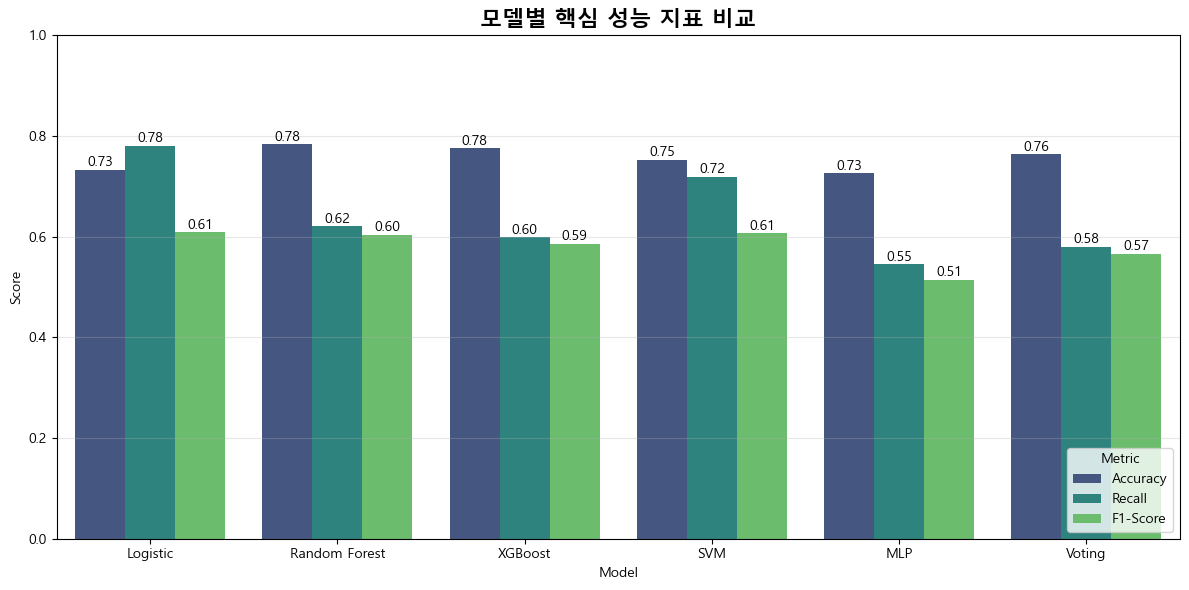

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 평가 함수 정의
def get_metrics_df(y_test, predictions_dict):
    metrics = []
    for model_name, y_pred in predictions_dict.items():
        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        metrics.append({
            'Model': model_name,
            'Accuracy': acc,
            'Recall': rec,
            'F1-Score': f1
        })
    return pd.DataFrame(metrics)

# 데이터 준비
preds = {
    'Logistic': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'SVM': y_pred_svm,
    'MLP': y_pred_mlp,
    'Voting': y_pred_vote
}

# 결과 데이터프레임 생성
results_df = get_metrics_df(y_test, preds)

# 막대 그래프 시각화
plt.figure(figsize = (12, 6))

# 데이터 형태 변환
melted_df = results_df.melt(id_vars = 'Model', value_vars = ['Accuracy', 'Recall', 'F1-Score'], 
                            var_name = 'Metric', value_name = 'Score')

# 막대 그래프 그리기
ax = sns.barplot(data = melted_df, x = 'Model', y = 'Score', hue = 'Metric', palette = 'viridis')

plt.title('모델별 핵심 성능 지표 비교', fontsize = 16, fontweight = 'bold')
plt.ylim(0, 1.0)
plt.legend(loc = 'lower right', title = 'Metric')
plt.grid(axis = 'y', alpha = 0.3)

# 막대 위에 수치 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points', fontsize = 10)

plt.tight_layout()
plt.show()

그래프를 통해 비교

로지스틱 회귀(78%)를 제외한 나머지 전체적으로 '재현율'이 낮은 문제를 발견

In [25]:
# 상세 성능 점수표 출력
print("모델별 상세 성능 점수표 (Recall 순 정렬) \n")
# 포맷팅하여 출력
display_df = results_df.sort_values(by = 'Recall', ascending = False)

display(display_df)

모델별 상세 성능 점수표 (Recall 순 정렬) 



,Model,Accuracy,Recall,F1-Score
0,Logistic,0.732765,0.780749,0.608333
3,SVM,0.752665,0.719251,0.607223
1,Random Forest,0.783937,0.620321,0.604167
2,XGBoost,0.775409,0.598930,0.586387
5,Voting,0.763326,0.580214,0.565841
4,MLP,0.726368,0.545455,0.514502


모델마다 문제가 존재

1. 랜덤포레스트: 나무 깊이 제한이 없음; 가중치 부여 필요
2. XGBoost: 정확도를 우선해 잔존 위주로 학습; 가중치 부여 필요
3. 서포트 벡터 머신: 재현율 72%로 불필요 하다고 판단되지만 시도해봄; 가중치 부여
4. 인공신경망: 데이터 양이 적음; 은닉층 쌓거나 노드 수 늘리기, 학습 횟수 증량
5. 보팅 앙상블: 이전 기법들을 개선 시 재현율 상승할 것이라 예측

In [26]:
print(" --- 랜덤 포레스트 --- \n")

# 모델 생성
model_rf = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', max_depth = 10, random_state = 42)

# 학습
model_rf.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_rf = model_rf.predict(X_test_scaled)
y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_rf):.4f}")

print(classification_report(y_test, y_pred_rf))

 --- 랜덤 포레스트 --- 

정확도: 0.7640
ROC-AUC: 0.8327
재현율: 0.7353
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1033
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.76      0.77      1407



랜덤 포레스트

class_weight = 'balanced': 비율이 적은 이탈 데이터에 가중치 부여

max_depth = 10: 깊이 제한, 과적합 방지

두 옵션을 사용해 재현율 62% -> 73%

약 11% 증가

In [27]:
print(" --- XGBoost --- \n")

# 모델 생성
model_xgb = XGBClassifier(eval_metric = 'logloss', scale_pos_weight = 3, random_state = 42)

# 학습
model_xgb.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_xgb = model_xgb.predict(X_test_scaled)
y_prob_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_xgb):.4f}")

print(classification_report(y_test, y_pred_xgb))

 --- XGBoost --- 

정확도: 0.7399
ROC-AUC: 0.8107
재현율: 0.7433
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.74      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.74      0.75      1407



XGBoost

scale_pos_weight = 3: 이탈자 맞추는 것에 가중치 3배 부여(잔존과 이탈 비율이 2.7배로 약 3이므로)

재현율 59% -> 74%

약 15% 증가

In [28]:
print(" --- 서포트 벡터 머신(SVM) --- \n")

# 모델 생성
model_svm = SVC(kernel = 'rbf', probability = True, class_weight = 'balanced', random_state = 42)

# 학습
model_svm.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_svm = model_svm.predict(X_test_scaled)
y_prob_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_svm):.4f}")

print(classification_report(y_test, y_pred_svm))

 --- 서포트 벡터 머신(SVM) --- 

정확도: 0.7527
ROC-AUC: 0.8074
재현율: 0.7193
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



서포트 벡터 머신

class_weight = 'balanced' 사용하였으나 모든 지표가 일치하게 나옴

In [29]:
print(" --- 인공신경망(MLP) --- \n")

# 모델 생성
model_mlp = MLPClassifier(hidden_layer_sizes = (100, 50, 25), max_iter = 1000, random_state = 42)

# 학습
model_mlp.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_mlp = model_mlp.predict(X_test_scaled)
y_prob_mlp = model_mlp.predict_proba(X_test_scaled)[:, 1]

print(f"정확도: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_mlp):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_mlp):.4f}")

print(classification_report(y_test, y_pred_mlp))

 --- 인공신경망(MLP) --- 

정확도: 0.7342
ROC-AUC: 0.7520
재현율: 0.5561
              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1033
           1       0.50      0.56      0.53       374

    accuracy                           0.73      1407
   macro avg       0.67      0.68      0.67      1407
weighted avg       0.74      0.73      0.74      1407



인공신경망

hidden_layer_sizes = (100, 50, 25): 은닉층을 늘려 복잡한 패턴 학습 유도

max_iter = 1000: 원래 학습 횟수 500에서 2배 증가한 수치

정확도 72% -> 73%, 재현율 54% -> 55%

지표에 살짝 변화가 발생했지만 유의미한 변화는 아니라고 판단

In [30]:
print(" --- 보팅 앙상블(Soft Voting) --- ")

voting_model = VotingClassifier(
    estimators = [
        ('RF', model_rf),   # 가중치 준 RF
        ('XGB', model_xgb), # 가중치 준 XGB
        ('SVM', model_svm)  # SVM으로 교체
    ],
    voting = 'soft'
)

# 학습
voting_model.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_vote = voting_model.predict(X_test_scaled)
y_prob_vote = voting_model.predict_proba(X_test_scaled)[:, 1]

# 평가
print(f"정확도: {accuracy_score(y_test, y_pred_vote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_vote):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_vote):.4f}")

print(classification_report(y_test, y_pred_vote))

 --- 보팅 앙상블(Soft Voting) --- 
정확도: 0.7584
ROC-AUC: 0.8262
재현율: 0.7353
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1033
           1       0.53      0.74      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



보팅 앙상블

인공신경망을 서포트 벡터 머신으로 교체하고 가중치 준 기법들로 다시 학습

재현율 58% -> 73%

약 15% 증가

여기에 로지스틱 모델도 넣어 학습시키면 어떨지 실험

In [31]:
print(" --- 보팅 앙상블(Soft Voting) --- ")

voting_model = VotingClassifier(
    estimators = [
        ('LR', model_lr),   # 로지스틱 추가
        ('RF', model_rf),   # 가중치 준 RF
        ('XGB', model_xgb), # 가중치 준 XGB
        ('SVM', model_svm)  # SVM으로 교체
    ],
    voting = 'soft'
)

# 학습
voting_model.fit(X_train_resampled, y_train_resampled)

# 예측
y_pred_vote = voting_model.predict(X_test_scaled)
y_prob_vote = voting_model.predict_proba(X_test_scaled)[:, 1]

# 평가
print(f"정확도: {accuracy_score(y_test, y_pred_vote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_vote):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_vote):.4f}")

print(classification_report(y_test, y_pred_vote))

 --- 보팅 앙상블(Soft Voting) --- 
정확도: 0.7562
ROC-AUC: 0.8309
재현율: 0.7487
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.76      0.77      1407



로지스틱 추가 전 73%에서 75%에 가깝게 상승

보팅 앙상블 모델에 재현율이 제일 높았던 로지스틱을 넣어도 많이 상승하지 않음

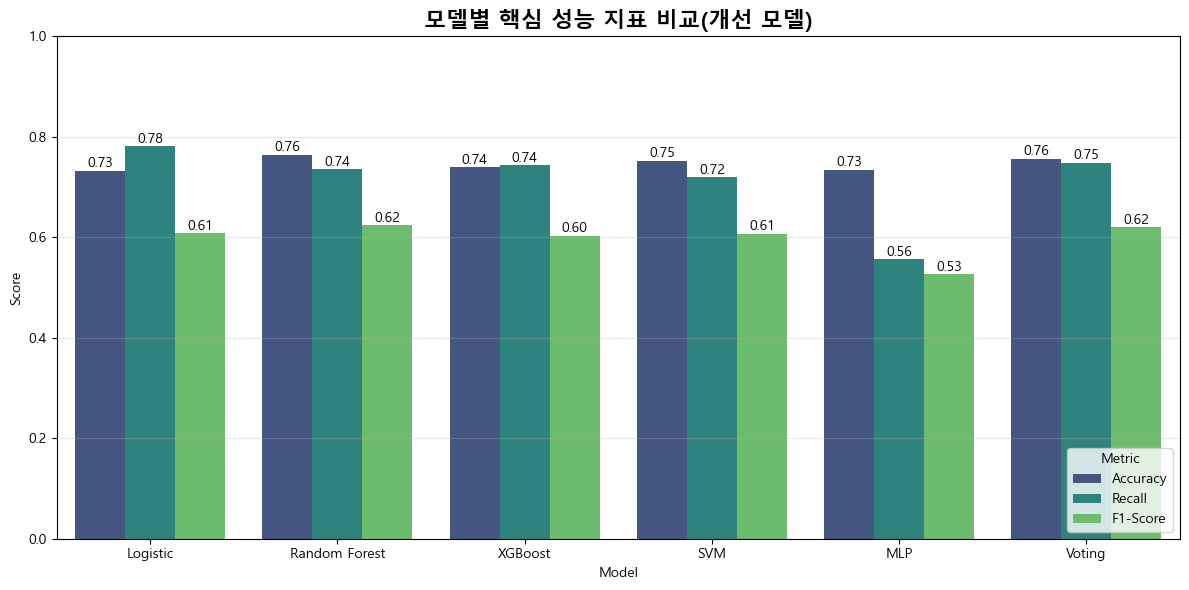

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# 평가 함수 정의
def get_metrics_df(y_test, predictions_dict):
    metrics = []
    for model_name, y_pred in predictions_dict.items():
        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        metrics.append({
            'Model': model_name,
            'Accuracy': acc,
            'Recall': rec,
            'F1-Score': f1
        })
    return pd.DataFrame(metrics)

# 데이터 준비
preds = {
    'Logistic': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'SVM': y_pred_svm,
    'MLP': y_pred_mlp,
    'Voting': y_pred_vote
}

# 결과 데이터프레임 생성
results_df = get_metrics_df(y_test, preds)

# 막대 그래프 시각화
plt.figure(figsize = (12, 6))

# 데이터 형태 변환
melted_df = results_df.melt(id_vars = 'Model', value_vars = ['Accuracy', 'Recall', 'F1-Score'], 
                            var_name = 'Metric', value_name = 'Score')

# 막대 그래프 그리기
ax = sns.barplot(data = melted_df, x = 'Model', y = 'Score', hue = 'Metric', palette = 'viridis')

plt.title('모델별 핵심 성능 지표 비교(개선 모델)', fontsize = 16, fontweight = 'bold')
plt.ylim(0, 1.0)
plt.legend(loc = 'lower right', title = 'Metric')
plt.grid(axis = 'y', alpha = 0.3)

# 막대 위에 수치 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points', fontsize = 10)

plt.tight_layout()
plt.show()

In [33]:
# 상세 성능 점수표 출력
print("모델별 상세 성능 점수표 (개선 모델) \n")
# 포맷팅하여 출력
display_df = results_df.sort_values(by = 'Recall', ascending = False)

display(display_df)

모델별 상세 성능 점수표 (개선 모델) 



,Model,Accuracy,Recall,F1-Score
0,Logistic,0.732765,0.780749,0.608333
5,Voting,0.756219,0.748663,0.620155
2,XGBoost,0.739872,0.743316,0.603037
1,Random Forest,0.764037,0.735294,0.623583
3,SVM,0.752665,0.719251,0.607223
4,MLP,0.734186,0.556150,0.526582


모델들의 문제점을 해결해 로지스틱 모델과 가깝게 재현율이 증가한 결과

하지만 여러 모델들을 살펴보아도 단일 모델인 로지스틱 회귀의 성능이 재현율 78%로 제일 높다는 것을 알 수 있음

각 변수들이 이탈 여부와 선형적 관계가 강하다고 해석

통신사 고객 이탈 예측에는 로지스틱 회귀가 성능이 가장 좋다고 판단

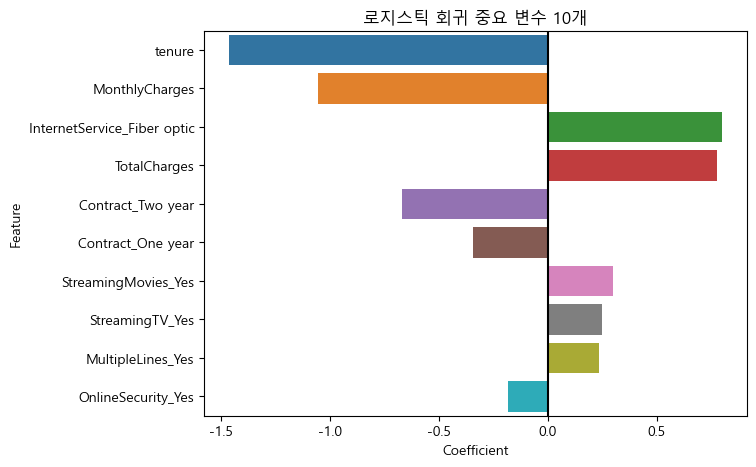

In [34]:
plt.rcParams['axes.unicode_minus'] = False

# 로지스틱 회귀 모델의 변수 중요도 시각화
coefs = model_lr.coef_[0]
features = X_train.columns
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by = 'Abs_Coefficient', ascending = False).head(10) # 상위 10개만

plt.figure(figsize = (7, 5))
sns.barplot(x = 'Coefficient', y = 'Feature', data = coef_df)
plt.title('로지스틱 회귀 중요 변수 10개')
plt.axvline(x = 0, color = 'black', linestyle = '-')
plt.show()

로지스틱 회귀 모델의 중요 변수 그래프

오른쪽(양수)으로 뻗은 막대는 이탈 위험 요인, 왼쪽(음수)으로 뻗은 막대는 잔존 요인

가입 기간(tenure)은 길어질수록 이탈 확률이 낮아지고,

광랜 인터넷(InternetService_Fiber optic)을 사용하면 이탈 확률이 높아진다고 해석

그런데 월 요금(MonthlyCharges)과 총 지불 금액(TotalCharges)의 그래프가 반대로 형성되는 것을 확인

서로의 영향력이 왜곡되진 않았는지 다중공산성 확인

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 수치형 데이터만 선택 (문자열/Object 컬럼 제외)
X_train_numeric = X_train.select_dtypes(include = ['int', 'float'])

# VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_numeric.columns

vif_data["VIF"] = [variance_inflation_factor(X_train_numeric.values, i)
                          for i in range(len(X_train_numeric.columns))]

vif_data = vif_data.sort_values(by = "VIF", ascending = False)
print(vif_data)

          feature       VIF
3    TotalCharges  8.164515
1          tenure  6.401405
2  MonthlyCharges  3.727258
0   SeniorCitizen  1.253664


TotalCharges는 8, tenure은6, MonthlyCharges는 3.7

VIF가 10을 넘지는 않지만 TotalCharges의 값은 높은 편

MonthlyCharges와 tenure로 계산되는 값이라 높을 것이라 생각되어 제거 후 재분석

In [41]:
# TotalCharges 컬럼 제거
X_train_reduced = X_train_numeric.drop(columns = ['TotalCharges'])

# VIF 계산
vif_data_new = pd.DataFrame()
vif_data_new["feature"] = X_train_reduced.columns

vif_data_new["VIF"] = [variance_inflation_factor(X_train_reduced.values, i)
                       for i in range(len(X_train_reduced.columns))]

# 3. 결과 출력 (높은 순서대로 정렬)
vif_data_new = vif_data_new.sort_values(by = "VIF", ascending = False)
print(vif_data_new)

          feature       VIF
2  MonthlyCharges  2.946068
1          tenure  2.642803
0   SeniorCitizen  1.252270


TotalCharges를 제거하니 MonthlyCharges의 VIF값이 2.9, tenure의 값이 2.6으로 하락

In [45]:
import statsmodels.api as sm

# 상수항 추가
X_train_new = sm.add_constant(X_train_reduced)

model = sm.Logit(y_train, X_train_new).fit()

# 결과 출력
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.449934
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5625
Model:                          Logit   Df Residuals:                     5621
Method:                           MLE   Df Model:                            3
Date:                Tue, 16 Dec 2025   Pseudo R-squ.:                  0.2229
Time:                        16:23:23   Log-Likelihood:                -2530.9
converged:                       True   LL-Null:                       -3257.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7928      0.097    -18.426      0.000      -1.984      -1.602
SeniorCitizen    

현재 로지스틱 회귀 모델은 약 19.8%의 설명력을 가짐

고령자(SeniorCitizen)일 수록 이탈 확률이 높아짐

사용 기간(tenure)이 길어질 수록 이탈 확률 낮아짐

월 요금(MonthlyCharges)은 원래 음수의 값을 가졌지만 TotalCharges를 제거하니 양수로 바뀜 (요금이 비쌀수록 이탈 확률이 높아짐)

가입 기간이 짧고, 월 요금을 많이 내며 고령자일 수록 이탈할 확률이 높은 것으로 판단